In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 20, dtype=np.float32)
_b = 1/(1 + np.exp(-x))
y = np.random.normal(_b, 0.005)

# 20x1
x = np.float32(x.reshape(-1, 1))
y = np.float32(y.reshape(-1, 1))

In [2]:
class LogicRegressionModel(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogicRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = torch.sigmoid(self.linear(x))
        return out

In [3]:
input_dim = 1
output_dim = 1
model = LogicRegressionModel(input_dim, output_dim)
criterion = torch.nn.BCELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [4]:
for epoch in range(100):
    epoch += 1
    # Convert numpy array to torch Variable
    inputs = torch.from_numpy(x).requires_grad_()
    labels = torch.from_numpy(y)

    # Clear gradients w.r.t. parameters
    optimizer.zero_grad()

    # Forward to get output
    outputs = model(inputs)

    # Calculate Loss
    loss = criterion(outputs, labels)

    # Getting gradients w.r.t. parameters
    loss.backward()

    # Updating parameters
    optimizer.step()

    print('epoch {}, loss {}'.format(epoch, loss.item()))

epoch 1, loss 1.9855797290802002
epoch 2, loss 1.9370615482330322
epoch 3, loss 1.889139175415039
epoch 4, loss 1.841840386390686
epoch 5, loss 1.7951939105987549
epoch 6, loss 1.749228835105896
epoch 7, loss 1.7039740085601807
epoch 8, loss 1.6594594717025757
epoch 9, loss 1.615714430809021
epoch 10, loss 1.5727678537368774
epoch 11, loss 1.5306484699249268
epoch 12, loss 1.4893839359283447
epoch 13, loss 1.4490010738372803
epoch 14, loss 1.4095252752304077
epoch 15, loss 1.3709803819656372
epoch 16, loss 1.3333885669708252
epoch 17, loss 1.296769618988037
epoch 18, loss 1.2611408233642578
epoch 19, loss 1.2265174388885498
epoch 20, loss 1.19291090965271
epoch 21, loss 1.160330891609192
epoch 22, loss 1.128782868385315
epoch 23, loss 1.0982697010040283
epoch 24, loss 1.0687909126281738
epoch 25, loss 1.0403425693511963
epoch 26, loss 1.0129179954528809
epoch 27, loss 0.9865069389343262
epoch 28, loss 0.9610964059829712
epoch 29, loss 0.9366706609725952
epoch 30, loss 0.913211524486541

标签Y: [[0.01507194]
 [0.01134836]
 [0.00482376]
 [0.03410879]
 [0.04424263]
 [0.09525884]
 [0.13563597]
 [0.20550123]
 [0.32090116]
 [0.42821223]
 [0.56885064]
 [0.6853778 ]
 [0.78544104]
 [0.863279  ]
 [0.9134765 ]
 [0.9432341 ]
 [0.96858126]
 [0.9781607 ]
 [0.99108297]
 [0.99520236]]
预测Y: [[0.0925867 ]
 [0.11218134]
 [0.13530454]
 [0.16232255]
 [0.19352818]
 [0.22909218]
 [0.2690117 ]
 [0.31306243]
 [0.36076644]
 [0.4113863 ]
 [0.46395373]
 [0.5173346 ]
 [0.5703227 ]
 [0.6217469 ]
 [0.6705716 ]
 [0.7159729 ]
 [0.75738114]
 [0.7944852 ]
 [0.82720953]
 [0.8556697 ]]


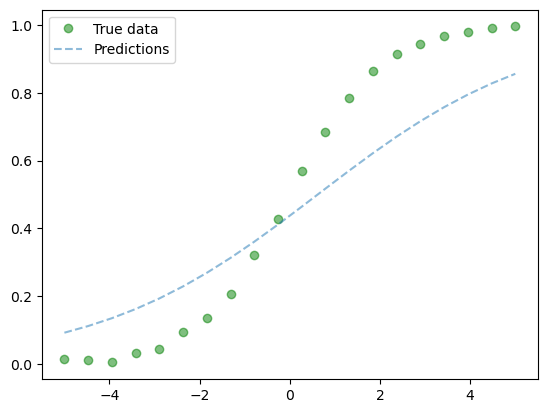

In [5]:
# Purely inference
predicted_y = model(torch.from_numpy(x).requires_grad_()).data.numpy()
print("标签Y:", y)
print("预测Y:", predicted_y)

# Clear figure
plt.clf()

# Get predictions
# predicted = model(torch.from_numpy(x).requires_grad_()).data.numpy()

# Plot true data
plt.plot(x, y, 'go', label='True data', alpha=0.5)

# Plot predictions
plt.plot(x, predicted_y, '--', label='Predictions', alpha=0.5)

# Legend and plot
plt.legend(loc='best')
plt.show()